<a href="https://colab.research.google.com/github/joolsa/PersonaBase/blob/main/Notebooks/PE06b_Persona_leaderboard.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PersonaBase Leaderboard (Standardized Metrics)

## Dataset
Download from: https://www.dropbox.com/scl/fi/i1idgttdw2fcr3dbspyje/DS06_YT.csv?rlkey=pyj1icys7mlxk7zgkp5epbk13&dl=0

Save as 'data.csv' in your working directory.

## Setup and Imports

In [29]:
!pip install umap

  Preparing metadata (setup.py) ... done
  Created wheel for umap: filename=umap-0.1.1-py3-none-any.whl size=3541 sha256=8ddc655b3ce7ad2fba35a0eb6b7ad32530d98daaff2e1fcbbc494c872a8c6a08
  Stored in directory: /root/.cache/pip/wheels/48/4a/1c/1d511cbb0413a448d8546e958f8e82b98d9bb493038d19ece2
Successfully built umap


In [30]:
from sklearn.decomposition import NMF, PCA
from sklearn import cluster
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import entropy
from scipy.spatial.distance import euclidean
import warnings
from sklearn.manifold import SpectralEmbedding  # add
import umap
warnings.filterwarnings('ignore')

np.random.seed(42)

print("="*80)
print("PersonaBase: Persona Generation & Evaluation Framework")
print("All metrics standardized: HIGHER = BETTER")
print("="*80)

PersonaBase: Persona Generation & Evaluation Framework
All metrics standardized: HIGHER = BETTER


In [35]:
# Robust UMAP import (handles different umap-learn packaging variants)
try:
    from umap import UMAP as _UMAP
except Exception:
    try:
        import umap
        _UMAP = umap.UMAP
    except Exception:
        import umap.umap_ as _umap_mod
        _UMAP = _umap_mod.UMAP


## Part 1: Data Loading

In [31]:
def load_data(filepath='data.csv'):
    """
    Load dataset and extract numeric features only
    Matches PersonaBase_PE05_Algorithm_comparison approach
    """
    df = pd.read_csv(filepath)
    print(f"\nDataset loaded: {df.shape}")

    # Extract only numeric columns (behavioral features)
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    original_features = df[numeric_cols]
    print(f"Numeric features extracted: {original_features.shape}")
    print(f"  - Number of demographics: {original_features.shape[0]}")
    print(f"  - Number of features: {original_features.shape[1]}")

    # Get demographic labels from 'Unnamed: 0' column
    demographic_labels = df['Unnamed: 0']
    print(f"\nSample demographic labels:")
    print(f"  {demographic_labels.head(3).tolist()}")

    return df, original_features, demographic_labels


# Load the data
df, original_features, demographic_labels = load_data('data.csv')


Dataset loaded: (1954, 12347)
Numeric features extracted: (1954, 12346)
  - Number of demographics: 1954
  - Number of features: 12346

Sample demographic labels:
  ['AE_13-17_female', 'AE_13-17_male', 'AE_18-24_female']


## Part 2: Demographic Parsing Functions

In [32]:
def parse_demographic_label(label):
    """
    Parse COUNTRY_AGE_GENDER format from Unnamed: 0 column
    Example: 'US_25-34_male' -> ('US', '25-34', 'male')
    """
    parts = str(label).split('_')

    country = parts[0] if len(parts) > 0 else 'Unknown'
    age = parts[1] if len(parts) > 1 else 'Unknown'
    gender = parts[2] if len(parts) > 2 else 'Unknown'

    # Fix age format (65- should be 65+)
    if age == '65-':
        age = '65+'

    return country, age, gender


def extract_demographics_from_label(label):
    """Extract demographics as dictionary"""
    country, age, gender = parse_demographic_label(label)
    return {
        'country': country,
        'age': age,
        'gender': gender,
        'label': label
    }


def create_dataset_demographics(demographic_labels):
    """Parse all demographics in dataset for reference"""
    demographics = []
    for label in demographic_labels:
        demo = extract_demographics_from_label(label)
        demographics.append(demo)

    dataset_df = pd.DataFrame(demographics)

    print("\n" + "="*80)
    print("Dataset Demographics Distribution")
    print("="*80)
    print(f"Total demographics: {len(dataset_df)}")
    print(f"Unique countries: {dataset_df['country'].nunique()}")
    print(f"Unique age groups: {dataset_df['age'].nunique()}")
    print(f"Unique genders: {dataset_df['gender'].nunique()}")

    print("\n--- Top 10 Countries ---")
    print(dataset_df['country'].value_counts().head(10))

    print("\n--- Age Groups ---")
    print(dataset_df['age'].value_counts().sort_index())

    print("\n--- Genders ---")
    print(dataset_df['gender'].value_counts())

    return dataset_df


# Parse dataset demographics for reference
dataset_demographics = create_dataset_demographics(demographic_labels)


Dataset Demographics Distribution
Total demographics: 1954
Unique countries: 185
Unique age groups: 7
Unique genders: 2

--- Top 10 Countries ---
country
AE    14
AT    14
AM    14
BA    14
BR    14
BD    14
BE    14
AU    14
BY    14
FR    14
Name: count, dtype: int64

--- Age Groups ---
age
13-17    186
18-24    326
25-34    355
35-44    327
45-54    299
55-64    248
65+      213
Name: count, dtype: int64

--- Genders ---
gender
male      1019
female     935
Name: count, dtype: int64


## Part 3: Persona Generation Functions

In [36]:
def find_pca_representatives(original_features, demographic_labels, n_personas=5):
    """Generate personas using PCA"""
    pca = PCA(n_components=n_personas, random_state=42)
    principalComponents = pca.fit_transform(original_features)

    representatives = []
    for component_idx in range(principalComponents.shape[1]):
        component_scores = principalComponents[:, component_idx]
        max_idx = np.argmax(np.abs(component_scores))
        representative_demo = demographic_labels.iloc[max_idx]
        representatives.append(representative_demo)

    return representatives


def find_nmf_representatives(original_features, demographic_labels, n_personas=5):
    """Generate personas using NMF"""
    model = NMF(n_components=n_personas, random_state=42, max_iter=500)
    W = model.fit_transform(original_features)

    representatives = []
    for component_idx in range(W.shape[1]):
        component_loadings = W[:, component_idx]
        max_idx = np.argmax(component_loadings)
        representative_demo = demographic_labels.iloc[max_idx]
        representatives.append(representative_demo)

    return representatives


def find_clustering_representatives(original_features, demographic_labels, n_personas=5):
    """Generate personas using Feature Agglomeration (Clustering)"""
    agglo = cluster.FeatureAgglomeration(n_clusters=n_personas)
    agglo.fit(original_features)
    X_reduced = agglo.transform(original_features)

    representatives = []
    for cluster_idx in range(X_reduced.shape[1]):
        cluster_values = X_reduced[:, cluster_idx]
        max_idx = np.argmax(cluster_values)
        representative_demo = demographic_labels.iloc[max_idx]
        representatives.append(representative_demo)

    return representatives


def find_spectral_representatives(original_features, demographic_labels, n_personas=5, n_neighbors=10):
    """Generate personas using Spectral Embedding (Laplacian Eigenmaps)
    - Reduce to `n_personas` dimensions
    - For each dimension, pick the sample with the largest absolute coordinate as the representative
    """
    from sklearn.manifold import SpectralEmbedding
    embedding = SpectralEmbedding(n_components=n_personas, n_neighbors=n_neighbors, random_state=42)
    coords = embedding.fit_transform(original_features)

    representatives = []
    for dim in range(coords.shape[1]):
        dim_vals = coords[:, dim]
        max_idx = np.argmax(np.abs(dim_vals))
        representatives.append(demographic_labels.iloc[max_idx])
    return representatives


def find_umap_representatives(original_features, demographic_labels, n_personas=5, n_neighbors=15, min_dist=0.1):
    """Generate personas using UMAP
    - Reduce to `n_personas` dimensions
    - For each dimension, pick the sample with the largest absolute coordinate as the representative
    """
    reducer = _UMAP(n_components=n_personas, n_neighbors=n_neighbors, min_dist=min_dist, random_state=42)
    coords = reducer.fit_transform(original_features)

    representatives = []
    for dim in range(coords.shape[1]):
        dim_vals = coords[:, dim]
        max_idx = np.argmax(np.abs(dim_vals))
        representatives.append(demographic_labels.iloc[max_idx])
    return representatives



def representatives_to_dataframe(representatives):
    """Convert list of representative labels to dataframe with demographics"""
    demographics = []
    for label in representatives:
        demo = extract_demographics_from_label(label)
        demographics.append(demo)

    return pd.DataFrame(demographics)

## Part 4: Generate All Persona Sets

In [37]:
# Define algorithms
algorithms = {
    'PCA': find_pca_representatives,
    'NMF': find_nmf_representatives,
    'Clustering': find_clustering_representatives,
    'Spectral': find_spectral_representatives,
    'UMAP': find_umap_representatives
}

# Define k values to test
k_values = [5, 10, 15]

# Generate all persona sets
all_persona_sets = {}

print("\n" + "="*80)
print("GENERATING PERSONA SETS")
print("="*80)

for algo_name, algo_func in algorithms.items():
    print(f"\n{algo_name}:")
    all_persona_sets[algo_name] = {}

    for k in k_values:
        representatives = algo_func(original_features, demographic_labels, n_personas=k)
        persona_df = representatives_to_dataframe(representatives)
        all_persona_sets[algo_name][k] = persona_df

        print(f"  k={k}: {len(persona_df)} personas generated")

print("\n" + "="*80)
print("✓ All persona sets generated successfully")
print("="*80)


GENERATING PERSONA SETS

PCA:
  k=5: 5 personas generated
  k=10: 10 personas generated
  k=15: 15 personas generated

NMF:
  k=5: 5 personas generated
  k=10: 10 personas generated
  k=15: 15 personas generated

Clustering:
  k=5: 5 personas generated
  k=10: 10 personas generated
  k=15: 15 personas generated

Spectral:
  k=5: 5 personas generated
  k=10: 10 personas generated
  k=15: 15 personas generated

UMAP:
  k=5: 5 personas generated
  k=10: 10 personas generated
  k=15: 15 personas generated

✓ All persona sets generated successfully


## Part 5: Evaluation Metrics Setup

In [38]:
# Calculate total unique attributes for diversity metric
total_unique_attrs = (
    dataset_demographics['country'].nunique() +
    dataset_demographics['age'].nunique() +
    dataset_demographics['gender'].nunique()
)

print(f"\nTotal unique demographic attributes: {total_unique_attrs}")


Total unique demographic attributes: 194


## Part 6: Metric Functions (Standardized)

In [39]:
def calculate_diversity(persona_df, total_unique_attrs):
    """
    Diversity = percentage of unique demographic attributes covered
    HIGHER IS BETTER (0-100%)
    """
    unique_countries = persona_df['country'].nunique()
    unique_ages = persona_df['age'].nunique()
    unique_genders = persona_df['gender'].nunique()

    total_unique = unique_countries + unique_ages + unique_genders
    diversity_score = (total_unique / total_unique_attrs) * 100

    return {
        'unique_countries': unique_countries,
        'unique_ages': unique_ages,
        'unique_genders': unique_genders,
        'total_unique': total_unique,
        'diversity_score': diversity_score
    }


def calculate_fairness(persona_df, dataset_demographics):
    """
    Fairness = inverse of statistical parity (REVERSE CODED)
    HIGHER IS BETTER (0-100, where 100 = perfect fairness)

    Original: Statistical Parity = |% in personas - % in dataset|
    Standardized: 100 - (average statistical parity)
    """
    k = len(persona_df)
    n_total = len(dataset_demographics)

    stat_parity_scores = []

    # Gender fairness
    for gender in dataset_demographics['gender'].unique():
        pct_dataset = (dataset_demographics['gender'] == gender).sum() / n_total * 100
        pct_personas = (persona_df['gender'] == gender).sum() / k * 100
        stat_parity = abs(pct_personas - pct_dataset)
        stat_parity_scores.append(stat_parity)

    # Age fairness
    for age in dataset_demographics['age'].unique():
        pct_dataset = (dataset_demographics['age'] == age).sum() / n_total * 100
        pct_personas = (persona_df['age'] == age).sum() / k * 100
        stat_parity = abs(pct_personas - pct_dataset)
        stat_parity_scores.append(stat_parity)

    # Country fairness
    for country in dataset_demographics['country'].unique():
        pct_dataset = (dataset_demographics['country'] == country).sum() / n_total * 100
        pct_personas = (persona_df['country'] == country).sum() / k * 100
        stat_parity = abs(pct_personas - pct_dataset)
        stat_parity_scores.append(stat_parity)

    # Calculate average statistical parity
    avg_stat_parity = np.mean(stat_parity_scores)

    # REVERSE CODE: Convert so higher = better
    # Max possible deviation is 100 (if one group has 100% in personas, 0% in data)
    fairness_score = 100 - avg_stat_parity

    return fairness_score


def calculate_consistency(algo_name, all_persona_sets, k_values):
    """
    Consistency = how much smaller persona sets are contained in larger sets
    HIGHER IS BETTER (0-100%, where 100% = perfect consistency)

    Already in correct direction, just convert to percentage
    """
    k_sorted = sorted(k_values)

    def get_persona_signatures(persona_df):
        signatures = set()
        for _, row in persona_df.iterrows():
            sig = f"{row['country']}_{row['age']}_{row['gender']}"
            signatures.add(sig)
        return signatures

    signatures = {k: get_persona_signatures(all_persona_sets[algo_name][k]) for k in k_sorted}

    consistency_scores = []
    for i in range(len(k_sorted) - 1):
        k_small = k_sorted[i]
        k_large = k_sorted[i + 1]

        small_set = signatures[k_small]
        large_set = signatures[k_large]

        overlap = len(small_set.intersection(large_set))
        overlap_pct = overlap / len(small_set) if len(small_set) > 0 else 0
        consistency_scores.append(overlap_pct)

    # Convert to percentage (0-100)
    consistency_score = np.mean(consistency_scores) * 100 if consistency_scores else 0

    return consistency_score


def calculate_coverage(persona_df, original_features, demographic_labels):
    """
    Coverage = inverse of average minimum distance (REVERSE CODED)
    HIGHER IS BETTER (0-100, where 100 = perfect coverage)

    Original: Lower distance = better coverage
    Standardized: Convert to similarity score where higher = better
    """
    # Get indices of personas
    persona_labels = persona_df['label'].values
    persona_indices = []

    for label in persona_labels:
        idx = demographic_labels[demographic_labels == label].index
        if len(idx) > 0:
            persona_indices.append(idx[0])

    if len(persona_indices) == 0:
        return 0.0  # Worst possible coverage

    # Get feature vectors for personas
    persona_features = original_features.iloc[persona_indices].values

    # Normalize features
    scaler = StandardScaler()
    all_features_scaled = scaler.fit_transform(original_features.values)
    persona_features_scaled = all_features_scaled[persona_indices]

    # Calculate minimum distance from each point to nearest persona
    min_distances = []
    for i in range(len(all_features_scaled)):
        distances = [euclidean(all_features_scaled[i], persona_features_scaled[j])
                    for j in range(len(persona_features_scaled))]
        min_distances.append(min(distances))

    # Average minimum distance
    avg_min_distance = np.mean(min_distances)

    # REVERSE CODE: Convert to coverage score where higher = better
    # Use exponential decay to convert distance to similarity
    # Coverage = 100 * exp(-avg_min_distance)
    # This gives 100 for perfect coverage (distance=0) and approaches 0 for poor coverage
    coverage_score = 100 * np.exp(-avg_min_distance)

    return coverage_score

## Part 7: Calculate All Metrics

In [40]:
print("\n" + "="*80)
print("CALCULATING METRICS (All Standardized: Higher = Better)")
print("="*80)

# DIVERSITY
print("\nCalculating Diversity...")
diversity_results = []

for algo_name in algorithms.keys():
    for k in k_values:
        persona_df = all_persona_sets[algo_name][k]
        diversity = calculate_diversity(persona_df, total_unique_attrs)

        diversity_results.append({
            'Algorithm': algo_name,
            'k': k,
            'Unique_Countries': diversity['unique_countries'],
            'Unique_Ages': diversity['unique_ages'],
            'Unique_Genders': diversity['unique_genders'],
            'Total_Unique': diversity['total_unique'],
            'Diversity_Score': diversity['diversity_score']
        })

diversity_df = pd.DataFrame(diversity_results)
print("✓ Diversity calculated (Higher = Better)")

# FAIRNESS
print("Calculating Fairness...")
fairness_results = []

for algo_name in algorithms.keys():
    for k in k_values:
        persona_df = all_persona_sets[algo_name][k]
        fairness_score = calculate_fairness(persona_df, dataset_demographics)

        fairness_results.append({
            'Algorithm': algo_name,
            'k': k,
            'Fairness_Score': fairness_score
        })

fairness_df = pd.DataFrame(fairness_results)
print("✓ Fairness calculated (Higher = Better, REVERSE CODED)")

# CONSISTENCY
print("Calculating Consistency...")
consistency_results = []

for algo_name in algorithms.keys():
    consistency_score = calculate_consistency(algo_name, all_persona_sets, k_values)

    consistency_results.append({
        'Algorithm': algo_name,
        'Consistency_Score': consistency_score
    })

consistency_df = pd.DataFrame(consistency_results)
print("✓ Consistency calculated (Higher = Better)")

# COVERAGE
print("Calculating Coverage...")
coverage_results = []

for algo_name in algorithms.keys():
    for k in k_values:
        persona_df = all_persona_sets[algo_name][k]
        coverage_score = calculate_coverage(persona_df, original_features, demographic_labels)

        coverage_results.append({
            'Algorithm': algo_name,
            'k': k,
            'Coverage_Score': coverage_score
        })

coverage_df = pd.DataFrame(coverage_results)
print("✓ Coverage calculated (Higher = Better, REVERSE CODED)")

print("\n" + "="*80)
print("All metrics calculated successfully")
print("ALL METRICS NOW STANDARDIZED: HIGHER = BETTER")
print("="*80)


CALCULATING METRICS (All Standardized: Higher = Better)

Calculating Diversity...
✓ Diversity calculated (Higher = Better)
Calculating Fairness...
✓ Fairness calculated (Higher = Better, REVERSE CODED)
Calculating Consistency...
✓ Consistency calculated (Higher = Better)
Calculating Coverage...
✓ Coverage calculated (Higher = Better, REVERSE CODED)

All metrics calculated successfully
ALL METRICS NOW STANDARDIZED: HIGHER = BETTER


## Part 8: Display Metric Results

In [41]:
print("\n" + "="*80)
print("METRIC RESULTS (All Higher = Better)")
print("="*80)

print("\n--- DIVERSITY SCORES (higher = better) ---")
print(diversity_df[['Algorithm', 'k', 'Total_Unique', 'Diversity_Score']].to_string(index=False))

print("\n--- FAIRNESS SCORES (higher = better) ---")
print(fairness_df.to_string(index=False))

print("\n--- CONSISTENCY SCORES (higher = better) ---")
print(consistency_df.to_string(index=False))

print("\n--- COVERAGE SCORES (higher = better) ---")
print(coverage_df.to_string(index=False))


METRIC RESULTS (All Higher = Better)

--- DIVERSITY SCORES (higher = better) ---
 Algorithm  k  Total_Unique  Diversity_Score
       PCA  5             8         4.123711
       PCA 10            11         5.670103
       PCA 15            14         7.216495
       NMF  5             8         4.123711
       NMF 10            12         6.185567
       NMF 15            14         7.216495
Clustering  5             7         3.608247
Clustering 10             8         4.123711
Clustering 15            11         5.670103
  Spectral  5            10         5.154639
  Spectral 10            18         9.278351
  Spectral 15            23        11.855670
      UMAP  5            11         5.670103
      UMAP 10            14         7.216495
      UMAP 15            22        11.340206

--- FAIRNESS SCORES (higher = better) ---
 Algorithm  k  Fairness_Score
       PCA  5       98.143802
       PCA 10       98.053583
       PCA 15       98.242076
       NMF  5       98.096952
     

## Part 9: Create Individual Metric Leaderboards

In [42]:
def create_leaderboard(df, metric_col, k_value=None):
    """Create ranked leaderboard for a metric (ALL HIGHER = BETTER)"""
    if k_value is not None:
        df_filtered = df[df['k'] == k_value].copy()
    else:
        df_filtered = df.copy()

    # Always sort descending since higher = better for all metrics
    df_sorted = df_filtered.sort_values(by=metric_col, ascending=False)
    df_sorted = df_sorted.reset_index(drop=True)
    df_sorted.index = df_sorted.index + 1
    df_sorted.index.name = 'Rank'

    return df_sorted


print("\n" + "="*80)
print("INDIVIDUAL METRIC LEADERBOARDS (All Higher = Better)")
print("="*80)

# DIVERSITY LEADERBOARDS
print("\n" + "="*60)
print("DIVERSITY LEADERBOARDS")
print("="*60)

diversity_leaderboards = {}
for k in k_values:
    print(f"\n--- k={k} personas ---")
    lb = create_leaderboard(diversity_df, 'Diversity_Score', k)
    diversity_leaderboards[k] = lb
    print(lb[['Algorithm', 'Diversity_Score']].to_string())

# FAIRNESS LEADERBOARDS
print("\n" + "="*60)
print("FAIRNESS LEADERBOARDS")
print("="*60)

fairness_leaderboards = {}
for k in k_values:
    print(f"\n--- k={k} personas ---")
    lb = create_leaderboard(fairness_df, 'Fairness_Score', k)
    fairness_leaderboards[k] = lb
    print(lb[['Algorithm', 'Fairness_Score']].to_string())

# CONSISTENCY LEADERBOARD
print("\n" + "="*60)
print("CONSISTENCY LEADERBOARD")
print("="*60)

consistency_leaderboard = create_leaderboard(consistency_df, 'Consistency_Score', None)
print(consistency_leaderboard.to_string())

# COVERAGE LEADERBOARDS
print("\n" + "="*60)
print("COVERAGE LEADERBOARDS")
print("="*60)

coverage_leaderboards = {}
for k in k_values:
    print(f"\n--- k={k} personas ---")
    lb = create_leaderboard(coverage_df, 'Coverage_Score', k)
    coverage_leaderboards[k] = lb
    print(lb[['Algorithm', 'Coverage_Score']].to_string())


INDIVIDUAL METRIC LEADERBOARDS (All Higher = Better)

DIVERSITY LEADERBOARDS

--- k=5 personas ---
       Algorithm  Diversity_Score
Rank                             
1           UMAP         5.670103
2       Spectral         5.154639
3            PCA         4.123711
4            NMF         4.123711
5     Clustering         3.608247

--- k=10 personas ---
       Algorithm  Diversity_Score
Rank                             
1       Spectral         9.278351
2           UMAP         7.216495
3            NMF         6.185567
4            PCA         5.670103
5     Clustering         4.123711

--- k=15 personas ---
       Algorithm  Diversity_Score
Rank                             
1       Spectral        11.855670
2           UMAP        11.340206
3            PCA         7.216495
4            NMF         7.216495
5     Clustering         5.670103

FAIRNESS LEADERBOARDS

--- k=5 personas ---
       Algorithm  Fairness_Score
Rank                            
1           UMAP       98.425

## Part 10: Create Aggregate Leaderboards

In [43]:
def normalize_score(values):
    """
    Normalize scores to 0-100 scale
    NO REVERSE needed since all metrics are already higher = better
    """
    vmin, vmax = values.min(), values.max()
    if vmax == vmin:
        return pd.Series([50.0] * len(values), index=values.index)

    normalized = ((values - vmin) / (vmax - vmin)) * 100
    return normalized


print("\n" + "="*80)
print("AGGREGATE LEADERBOARDS (All Metrics Combined)")
print("="*80)
print("\nAll metrics normalized to 0-100 scale (Higher = Better)")
print("Aggregate score = simple average (equal weights)")

aggregate_leaderboards = {}

for k in k_values:
    print(f"\n{'='*60}")
    print(f"k={k} personas")
    print(f"{'='*60}")

    # Merge all metrics for this k value
    div_k = diversity_df[diversity_df['k'] == k][['Algorithm', 'Diversity_Score']].copy()
    fair_k = fairness_df[fairness_df['k'] == k][['Algorithm', 'Fairness_Score']].copy()
    cov_k = coverage_df[coverage_df['k'] == k][['Algorithm', 'Coverage_Score']].copy()

    agg = div_k.merge(fair_k, on='Algorithm')
    agg = agg.merge(consistency_df[['Algorithm', 'Consistency_Score']], on='Algorithm')
    agg = agg.merge(cov_k, on='Algorithm')

    # Normalize each metric (NO REVERSE needed - all already higher = better)
    agg['Diversity_Normalized'] = normalize_score(agg['Diversity_Score'])
    agg['Fairness_Normalized'] = normalize_score(agg['Fairness_Score'])
    agg['Consistency_Normalized'] = normalize_score(agg['Consistency_Score'])
    agg['Coverage_Normalized'] = normalize_score(agg['Coverage_Score'])

    # Calculate aggregate score (simple average)
    agg['Aggregate_Score'] = (
        agg['Diversity_Normalized'] +
        agg['Fairness_Normalized'] +
        agg['Consistency_Normalized'] +
        agg['Coverage_Normalized']
    ) / 4

    # Sort and rank (descending since higher = better)
    agg = agg.sort_values('Aggregate_Score', ascending=False).reset_index(drop=True)
    agg.index = agg.index + 1
    agg.index.name = 'Rank'

    aggregate_leaderboards[k] = agg

    # Display normalized scores
    display_cols = ['Algorithm', 'Diversity_Normalized', 'Fairness_Normalized',
                   'Consistency_Normalized', 'Coverage_Normalized', 'Aggregate_Score']
    print(agg[display_cols].round(2).to_string())


AGGREGATE LEADERBOARDS (All Metrics Combined)

All metrics normalized to 0-100 scale (Higher = Better)
Aggregate score = simple average (equal weights)

k=5 personas
       Algorithm  Diversity_Normalized  Fairness_Normalized  Consistency_Normalized  Coverage_Normalized  Aggregate_Score
Rank                                                                                                                     
1       Spectral                  75.0                99.46                  100.00                 0.00            68.62
2            NMF                  25.0                16.27                   87.32               100.00            57.15
3           UMAP                 100.0               100.00                    0.00                 2.75            50.69
4            PCA                  25.0                28.20                  100.00                23.95            44.29
5     Clustering                   0.0                 0.00                  100.00                36

## Part 11: Overall Champion

In [44]:
print("\n" + "="*80)
print("OVERALL CHAMPION (Average Across All K Values)")
print("="*80)

# Calculate average aggregate score across all k values
overall_scores = {}

for algo_name in algorithms.keys():
    scores = []
    for k in k_values:
        agg_score = aggregate_leaderboards[k][
            aggregate_leaderboards[k]['Algorithm'] == algo_name
        ]['Aggregate_Score'].values[0]
        scores.append(agg_score)

    overall_scores[algo_name] = np.mean(scores)

# Sort by overall score (descending)
sorted_overall = sorted(overall_scores.items(), key=lambda x: x[1], reverse=True)

print("\nOverall Rankings:")
print("-" * 50)
for rank, (algo, score) in enumerate(sorted_overall, 1):
    medal = "🥇" if rank == 1 else "🥈" if rank == 2 else "🥉" if rank == 3 else "  "
    print(f"{medal} {rank}. {algo:15s} {score:6.2f}/100")

print("\n" + "="*80)
print(f"🏆 OVERALL CHAMPION: {sorted_overall[0][0]}")
print(f"   Average Aggregate Score: {sorted_overall[0][1]:.2f}/100")
print("="*80)


OVERALL CHAMPION (Average Across All K Values)

Overall Rankings:
--------------------------------------------------
🥇 1. Spectral         72.65/100
🥈 2. NMF              58.11/100
🥉 3. PCA              53.45/100
   4. UMAP             43.15/100
   5. Clustering       33.17/100

🏆 OVERALL CHAMPION: Spectral
   Average Aggregate Score: 72.65/100


## Part 12: Visualizations


✓ Dashboard saved: PersonaBase_dashboard_standardized.png


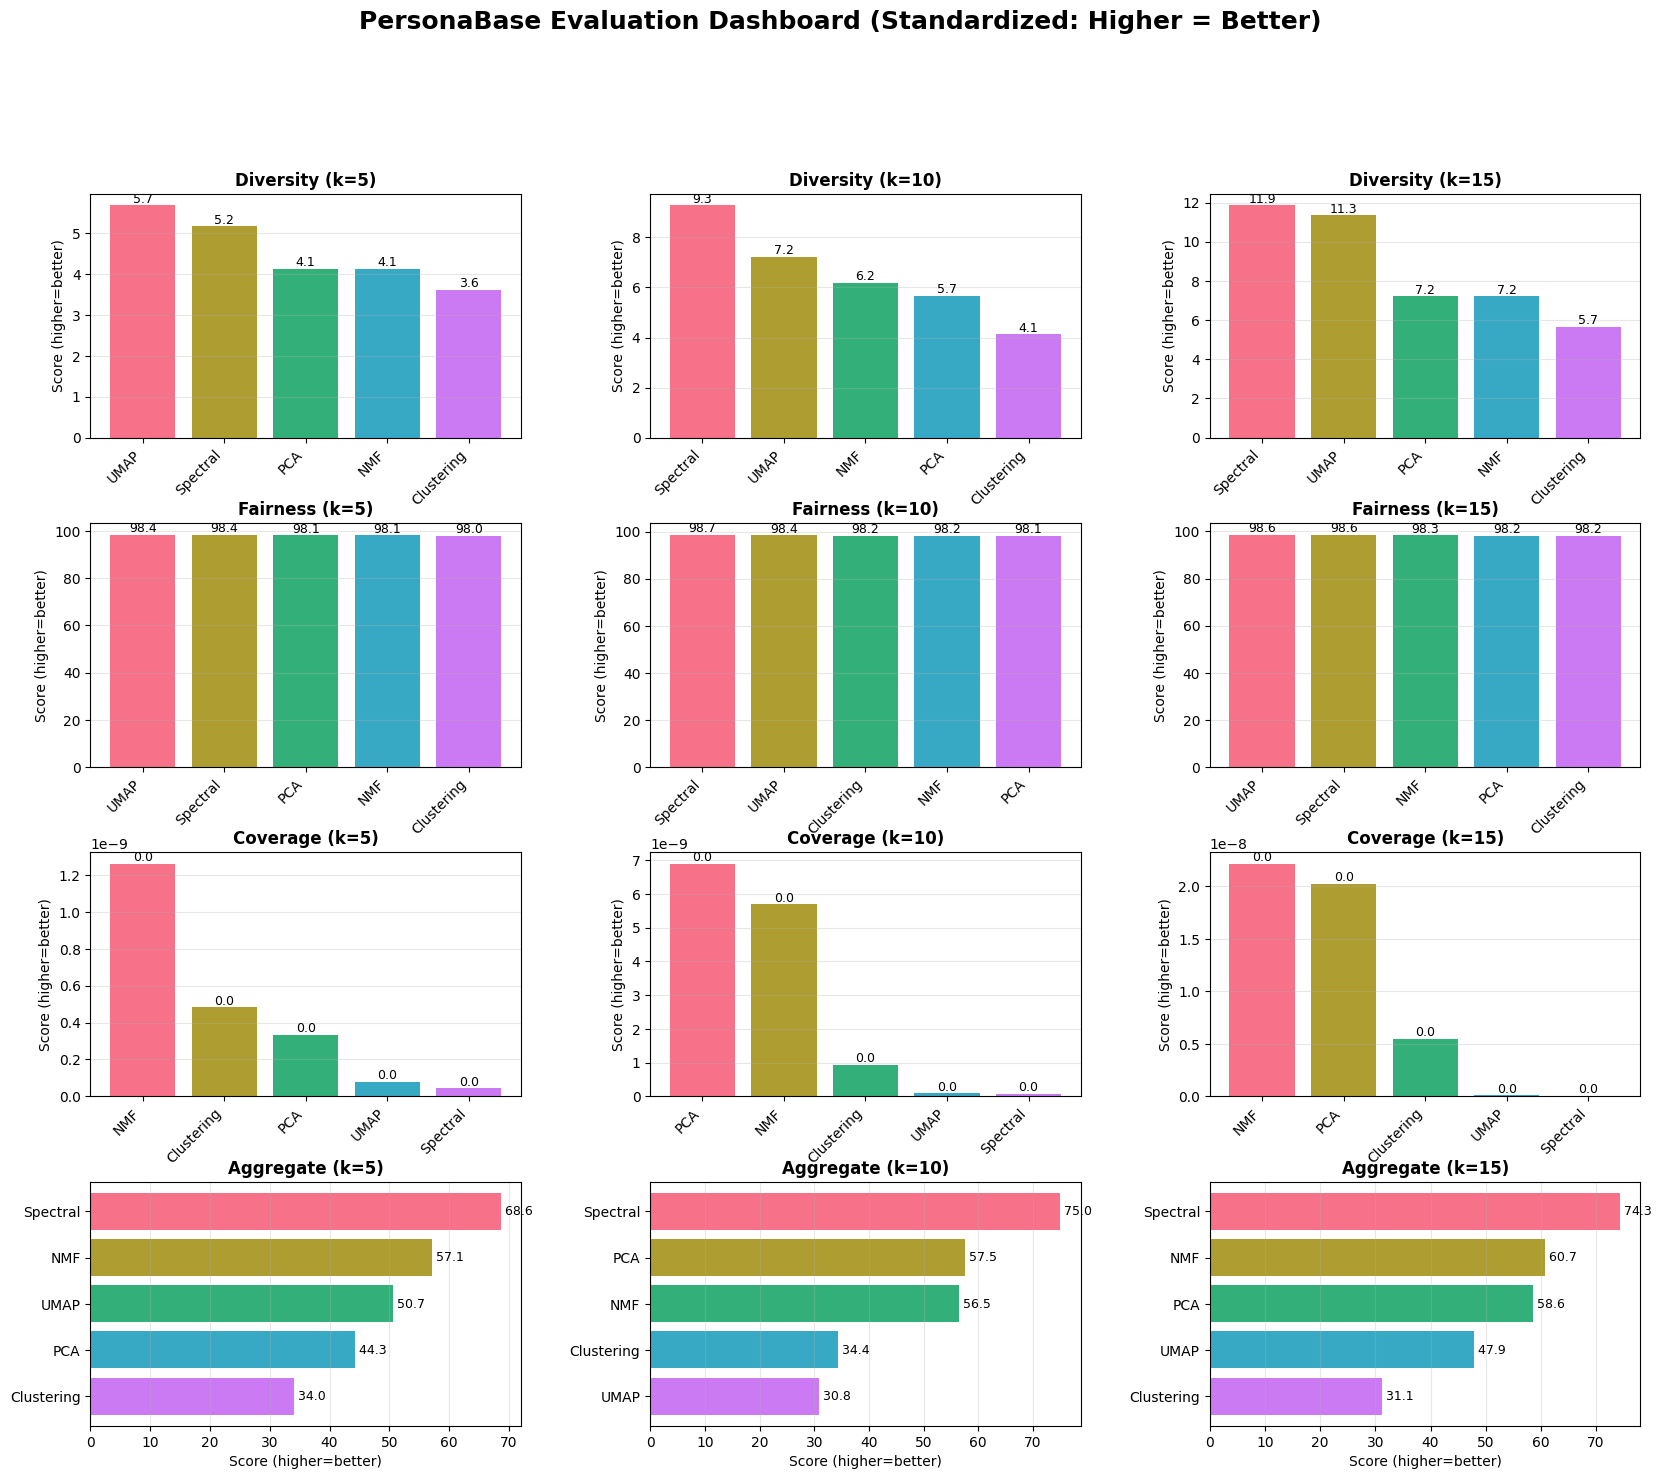

✓ Consistency chart saved: consistency_comparison.png


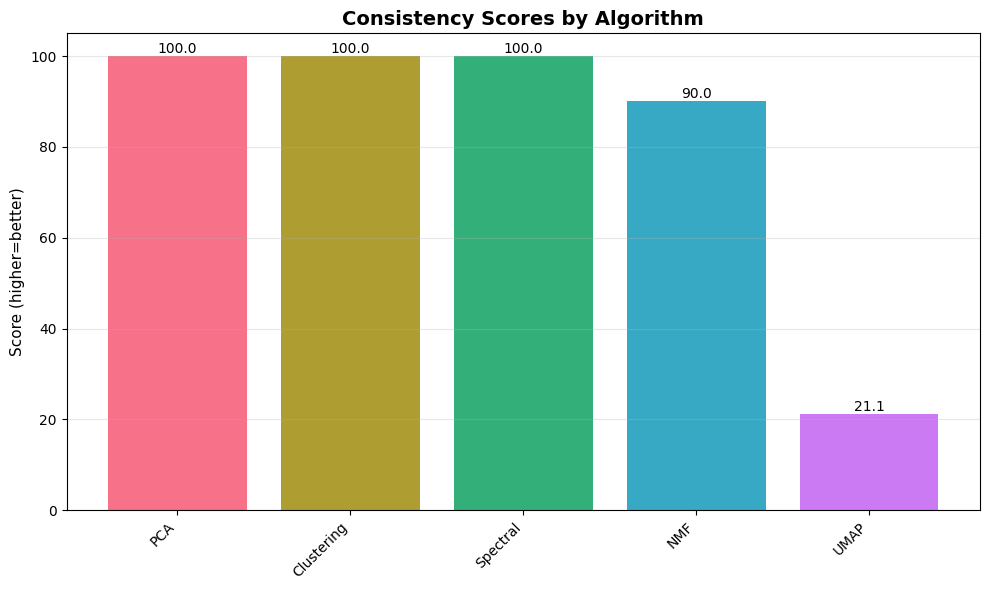

In [45]:
# Create comprehensive dashboard
fig = plt.figure(figsize=(20, 16))
gs = fig.add_gridspec(4, 3, hspace=0.35, wspace=0.3)
fig.suptitle('PersonaBase Evaluation Dashboard (Standardized: Higher = Better)',
             fontsize=18, fontweight='bold', y=0.995)

colors = sns.color_palette("husl", len(algorithms))

# Row 1: Diversity
for i, k in enumerate(k_values):
    ax = fig.add_subplot(gs[0, i])
    data = diversity_df[diversity_df['k'] == k].sort_values('Diversity_Score', ascending=False)
    bars = ax.bar(range(len(data)), data['Diversity_Score'], color=colors)
    ax.set_xticks(range(len(data)))
    ax.set_xticklabels(data['Algorithm'], rotation=45, ha='right', fontsize=10)
    ax.set_title(f'Diversity (k={k})', fontweight='bold', fontsize=12)
    ax.set_ylabel('Score (higher=better)', fontsize=10)
    ax.grid(axis='y', alpha=0.3)

    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
               f'{height:.1f}', ha='center', va='bottom', fontsize=9)

# Row 2: Fairness
for i, k in enumerate(k_values):
    ax = fig.add_subplot(gs[1, i])
    data = fairness_df[fairness_df['k'] == k].sort_values('Fairness_Score', ascending=False)
    bars = ax.bar(range(len(data)), data['Fairness_Score'], color=colors)
    ax.set_xticks(range(len(data)))
    ax.set_xticklabels(data['Algorithm'], rotation=45, ha='right', fontsize=10)
    ax.set_title(f'Fairness (k={k})', fontweight='bold', fontsize=12)
    ax.set_ylabel('Score (higher=better)', fontsize=10)
    ax.grid(axis='y', alpha=0.3)

    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
               f'{height:.1f}', ha='center', va='bottom', fontsize=9)

# Row 3: Coverage
for i, k in enumerate(k_values):
    ax = fig.add_subplot(gs[2, i])
    data = coverage_df[coverage_df['k'] == k].sort_values('Coverage_Score', ascending=False)
    bars = ax.bar(range(len(data)), data['Coverage_Score'], color=colors)
    ax.set_xticks(range(len(data)))
    ax.set_xticklabels(data['Algorithm'], rotation=45, ha='right', fontsize=10)
    ax.set_title(f'Coverage (k={k})', fontweight='bold', fontsize=12)
    ax.set_ylabel('Score (higher=better)', fontsize=10)
    ax.grid(axis='y', alpha=0.3)

    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
               f'{height:.1f}', ha='center', va='bottom', fontsize=9)

# Row 4: Aggregate
for i, k in enumerate(k_values):
    ax = fig.add_subplot(gs[3, i])
    data = aggregate_leaderboards[k].sort_values('Aggregate_Score', ascending=False)
    bars = ax.barh(range(len(data)), data['Aggregate_Score'], color=colors)
    ax.set_yticks(range(len(data)))
    ax.set_yticklabels(data['Algorithm'], fontsize=10)
    ax.set_title(f'Aggregate (k={k})', fontweight='bold', fontsize=12)
    ax.set_xlabel('Score (higher=better)', fontsize=10)
    ax.invert_yaxis()
    ax.grid(axis='x', alpha=0.3)

    for bar in bars:
        width = bar.get_width()
        ax.text(width, bar.get_y() + bar.get_height()/2.,
               f' {width:.1f}', ha='left', va='center', fontsize=9)

plt.savefig('PersonaBase_dashboard_standardized.png', dpi=300, bbox_inches='tight')
print("\n✓ Dashboard saved: PersonaBase_dashboard_standardized.png")
plt.show()

# Consistency chart
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
data = consistency_df.sort_values('Consistency_Score', ascending=False)
bars = ax.bar(range(len(data)), data['Consistency_Score'], color=colors)
ax.set_xticks(range(len(data)))
ax.set_xticklabels(data['Algorithm'], rotation=45, ha='right')
ax.set_title('Consistency Scores by Algorithm', fontsize=14, fontweight='bold')
ax.set_ylabel('Score (higher=better)', fontsize=11)
ax.grid(axis='y', alpha=0.3)

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
           f'{height:.1f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('consistency_comparison.png', dpi=300, bbox_inches='tight')
print("✓ Consistency chart saved: consistency_comparison.png")
plt.show()

## Part 13: Export Results

In [46]:
# Export all results to CSV
diversity_df.to_csv('results_diversity.csv', index=False)
fairness_df.to_csv('results_fairness.csv', index=False)
consistency_df.to_csv('results_consistency.csv', index=False)
coverage_df.to_csv('results_coverage.csv', index=False)

for k in k_values:
    aggregate_leaderboards[k].to_csv(f'results_aggregate_k{k}.csv')

# Create comprehensive summary report
with open('PersonaBase_summary.txt', 'w') as f:
    f.write("="*80 + "\n")
    f.write("PersonaBase EVALUATION SUMMARY REPORT\n")
    f.write("(Standardized Metrics: Higher = Better)\n")
    f.write("="*80 + "\n\n")

    # Overall Champion
    f.write("OVERALL CHAMPION\n")
    f.write("-"*80 + "\n")
    f.write(f"🏆 {sorted_overall[0][0]}\n")
    f.write(f"   Average Aggregate Score: {sorted_overall[0][1]:.2f}/100\n\n")

    # Overall Rankings
    f.write("OVERALL RANKINGS (Average Across All K Values)\n")
    f.write("-"*80 + "\n")
    for rank, (algo, score) in enumerate(sorted_overall, 1):
        f.write(f"{rank}. {algo:15s} {score:6.2f}/100\n")
    f.write("\n")

    # Top Performers by Metric and K
    f.write("TOP PERFORMERS BY METRIC\n")
    f.write("-"*80 + "\n\n")

    for k in k_values:
        f.write(f"k={k} Personas:\n")

        # Diversity winner
        div_winner = diversity_df[diversity_df['k'] == k].nlargest(1, 'Diversity_Score')
        f.write(f"  Diversity:   {div_winner['Algorithm'].values[0]:15s} "
               f"{div_winner['Diversity_Score'].values[0]:6.2f}\n")

        # Fairness winner
        fair_winner = fairness_df[fairness_df['k'] == k].nlargest(1, 'Fairness_Score')
        f.write(f"  Fairness:    {fair_winner['Algorithm'].values[0]:15s} "
               f"{fair_winner['Fairness_Score'].values[0]:6.2f}\n")

        # Coverage winner
        cov_winner = coverage_df[coverage_df['k'] == k].nlargest(1, 'Coverage_Score')
        f.write(f"  Coverage:    {cov_winner['Algorithm'].values[0]:15s} "
               f"{cov_winner['Coverage_Score'].values[0]:6.2f}\n")

        # Aggregate winner
        agg_winner = aggregate_leaderboards[k].head(1)
        f.write(f"  Aggregate:   {agg_winner['Algorithm'].values[0]:15s} "
               f"{agg_winner['Aggregate_Score'].values[0]:6.2f}\n\n")

    # Consistency winner
    f.write("Across All K Values:\n")
    cons_winner = consistency_df.nlargest(1, 'Consistency_Score')
    f.write(f"  Consistency: {cons_winner['Algorithm'].values[0]:15s} "
           f"{cons_winner['Consistency_Score'].values[0]:6.2f}\n\n")

    # Metric Definitions
    f.write("="*80 + "\n")
    f.write("METRIC DEFINITIONS (All Standardized: Higher = Better)\n")
    f.write("="*80 + "\n\n")

    f.write("1. Diversity\n")
    f.write("   Measures coverage of unique demographic attributes\n")
    f.write("   Score: 0-100 (higher = better)\n")
    f.write("   Formula: (unique attributes in personas / total attributes) × 100\n\n")

    f.write("2. Fairness (REVERSE CODED)\n")
    f.write("   Measures proportional representation vs. population\n")
    f.write("   Score: 0-100 (higher = better fairness)\n")
    f.write("   Formula: 100 - (average statistical parity deviation)\n")
    f.write("   Original metric: Statistical parity (lower was better)\n")
    f.write("   Standardized: Inverted so higher score = more fair\n\n")

    f.write("3. Consistency\n")
    f.write("   Measures stability of personas across set sizes\n")
    f.write("   Score: 0-100 (higher = better consistency)\n")
    f.write("   Formula: Average overlap of smaller sets in larger sets × 100\n\n")

    f.write("4. Coverage (REVERSE CODED)\n")
    f.write("   Measures behavioral space representation\n")
    f.write("   Score: 0-100 (higher = better coverage)\n")
    f.write("   Formula: 100 × exp(-average_minimum_distance)\n")
    f.write("   Original metric: Distance (lower was better)\n")
    f.write("   Standardized: Exponential decay transformation (higher = better)\n\n")

    f.write("5. Aggregate Score\n")
    f.write("   Combined score of all four metrics\n")
    f.write("   Score: 0-100 (higher = better)\n")
    f.write("   Formula: Average of normalized Diversity, Fairness, Consistency, Coverage\n")
    f.write("   Note: All metrics weighted equally (25% each)\n\n")

    f.write("STANDARDIZATION BENEFITS:\n")
    f.write("  • Consistent interpretation: Higher is always better\n")
    f.write("  • Easier comparison across metrics\n")
    f.write("  • Simplified aggregation (no need for reversal flags)\n")
    f.write("  • More intuitive for end users\n\n")

    # Dataset Info
    f.write("="*80 + "\n")
    f.write("DATASET INFORMATION\n")
    f.write("="*80 + "\n\n")
    f.write(f"Total demographics: {len(dataset_demographics)}\n")
    f.write(f"Unique countries: {dataset_demographics['country'].nunique()}\n")
    f.write(f"Unique age groups: {dataset_demographics['age'].nunique()}\n")
    f.write(f"Unique genders: {dataset_demographics['gender'].nunique()}\n")
    f.write(f"Total unique attributes: {total_unique_attrs}\n")
    f.write(f"Feature dimensions: {original_features.shape[1]}\n\n")

    # Algorithms tested
    f.write("="*80 + "\n")
    f.write("ALGORITHMS TESTED\n")
    f.write("="*80 + "\n\n")
    for algo in algorithms.keys():
        f.write(f"  • {algo}\n")
    f.write(f"\nPersona set sizes (k): {k_values}\n")

print("\n" + "="*80)
print("RESULTS EXPORTED")
print("="*80)
print("\n✓ CSV Files:")
print("  - results_diversity.csv")
print("  - results_fairness.csv")
print("  - results_consistency.csv")
print("  - results_coverage.csv")
for k in k_values:
    print(f"  - results_aggregate_k{k}.csv")
print("\n✓ Visualizations:")
print("  - PersonaBase_dashboard_standardized.png")
print("  - consistency_comparison.png")
print("\n✓ Summary Report:")
print("  - PersonaBase_summary.txt")
print("\n" + "="*80)
print("✅ EVALUATION COMPLETE!")
print("="*80)


RESULTS EXPORTED

✓ CSV Files:
  - results_diversity.csv
  - results_fairness.csv
  - results_consistency.csv
  - results_coverage.csv
  - results_aggregate_k5.csv
  - results_aggregate_k10.csv
  - results_aggregate_k15.csv

✓ Visualizations:
  - PersonaBase_dashboard_standardized.png
  - consistency_comparison.png

✓ Summary Report:
  - PersonaBase_summary.txt

✅ EVALUATION COMPLETE!


## Part 14: Standardization Summary

In [47]:
print("\n" + "="*80)
print("METRIC STANDARDIZATION SUMMARY")
print("="*80)

print("\n🎯 ALL METRICS NOW FOLLOW: HIGHER = BETTER\n")

print("Metrics and their standardization:")
print("-" * 80)

print("\n1. DIVERSITY")
print("   Original: 0-100% (higher was better)")
print("   Standardized: No change needed")
print("   Range: 0-100")

print("\n2. FAIRNESS")
print("   Original: 0+ statistical parity (LOWER was better)")
print("   Standardized: 100 - statistical_parity")
print("   Range: 0-100 (higher = more fair)")
print("   Transformation: REVERSE CODED")

print("\n3. CONSISTENCY")
print("   Original: 0-1 overlap ratio (higher was better)")
print("   Standardized: Multiplied by 100")
print("   Range: 0-100")

print("\n4. COVERAGE")
print("   Original: 0+ distance (LOWER was better)")
print("   Standardized: 100 × exp(-distance)")
print("   Range: 0-100 (higher = better coverage)")
print("   Transformation: REVERSE CODED with exponential decay")

print("\n" + "-" * 80)
print("\n✅ BENEFITS OF STANDARDIZATION:")
print("   • Consistent interpretation across all metrics")
print("   • Easier to compare algorithm performance")
print("   • Simplified aggregation (no reversal flags needed)")
print("   • More intuitive for stakeholders and end users")
print("   • All leaderboards sorted the same way (descending)")

print("\n" + "="*80)


METRIC STANDARDIZATION SUMMARY

🎯 ALL METRICS NOW FOLLOW: HIGHER = BETTER

Metrics and their standardization:
--------------------------------------------------------------------------------

1. DIVERSITY
   Original: 0-100% (higher was better)
   Standardized: No change needed
   Range: 0-100

2. FAIRNESS
   Original: 0+ statistical parity (LOWER was better)
   Standardized: 100 - statistical_parity
   Range: 0-100 (higher = more fair)
   Transformation: REVERSE CODED

3. CONSISTENCY
   Original: 0-1 overlap ratio (higher was better)
   Standardized: Multiplied by 100
   Range: 0-100

4. COVERAGE
   Original: 0+ distance (LOWER was better)
   Standardized: 100 × exp(-distance)
   Range: 0-100 (higher = better coverage)
   Transformation: REVERSE CODED with exponential decay

--------------------------------------------------------------------------------

✅ BENEFITS OF STANDARDIZATION:
   • Consistent interpretation across all metrics
   • Easier to compare algorithm performance
   •

## Part 15: Metric Comparison

In [48]:
print("\n" + "="*80)
print("METRIC CORRELATION ANALYSIS")
print("="*80)

for k in k_values:
    print(f"\n--- k={k} personas ---")

    # Merge all metrics
    analysis_df = diversity_df[diversity_df['k'] == k][['Algorithm', 'Diversity_Score']].copy()
    analysis_df = analysis_df.merge(
        fairness_df[fairness_df['k'] == k][['Algorithm', 'Fairness_Score']],
        on='Algorithm'
    )
    analysis_df = analysis_df.merge(
        coverage_df[coverage_df['k'] == k][['Algorithm', 'Coverage_Score']],
        on='Algorithm'
    )
    analysis_df = analysis_df.merge(
        consistency_df[['Algorithm', 'Consistency_Score']],
        on='Algorithm'
    )

    # Calculate correlations
    corr_matrix = analysis_df[['Diversity_Score', 'Fairness_Score',
                                'Coverage_Score', 'Consistency_Score']].corr()

    print("\nCorrelation Matrix:")
    print(corr_matrix.round(3))

    # Highlight interesting correlations
    print("\nKey Relationships:")
    for i, metric1 in enumerate(['Diversity_Score', 'Fairness_Score', 'Coverage_Score']):
        for metric2 in ['Diversity_Score', 'Fairness_Score', 'Coverage_Score', 'Consistency_Score'][i+1:]:
            corr = corr_matrix.loc[metric1, metric2]
            metric1_name = metric1.replace('_Score', '')
            metric2_name = metric2.replace('_Score', '')

            if abs(corr) > 0.5:
                direction = "positive" if corr > 0 else "negative"
                print(f"  {metric1_name} ↔ {metric2_name}: {corr:.3f} (strong {direction})")

print("\n" + "="*80)
print("Note: All correlations now use standardized scores (higher = better)")
print("="*80)


METRIC CORRELATION ANALYSIS

--- k=5 personas ---

Correlation Matrix:
                   Diversity_Score  Fairness_Score  Coverage_Score  \
Diversity_Score              1.000           0.972          -0.593   
Fairness_Score               0.972           1.000          -0.695   
Coverage_Score              -0.593          -0.695           1.000   
Consistency_Score           -0.731          -0.567           0.300   

                   Consistency_Score  
Diversity_Score               -0.731  
Fairness_Score                -0.567  
Coverage_Score                 0.300  
Consistency_Score              1.000  

Key Relationships:
  Diversity ↔ Fairness: 0.972 (strong positive)
  Diversity ↔ Coverage: -0.593 (strong negative)
  Diversity ↔ Consistency: -0.731 (strong negative)
  Fairness ↔ Coverage: -0.695 (strong negative)
  Fairness ↔ Consistency: -0.567 (strong negative)

--- k=10 personas ---

Correlation Matrix:
                   Diversity_Score  Fairness_Score  Coverage_Score  \


## Summary

**🎉 All metrics are now standardized: HIGHER IS ALWAYS BETTER**

### Key Changes:

1. **Fairness**: Reverse coded from statistical parity
   - Original: Lower deviation = better
   - Now: `100 - avg_statistical_parity` (higher = more fair)

2. **Coverage**: Reverse coded with exponential transformation
   - Original: Lower distance = better
   - Now: `100 × exp(-avg_distance)` (higher = better coverage)

3. **Diversity**: No change (already higher = better)

4. **Consistency**: Converted to percentage scale (0-100)

### Benefits:
- ✅ Consistent interpretation
- ✅ Easier comparison
- ✅ Simplified aggregation
- ✅ More intuitive
- ✅ All leaderboards sort the same way